# Project: Prompt Optimization for Financial Report Summarization

This notebook tests and compares different prompt styles for summarizing financial reports using GPT-3.5 via the OpenAI API. It evaluates how prompt phrasing affects output clarity, factual accuracy, and conciseness.

In [1]:
import openai
import os
import pandas as pd
import time
import json
from tqdm import tqdm
from datetime import datetime
import matplotlib.pyplot as plt  
from utils import evaluate_results, batch_process, query_gpt, format_report_as_text, load_reports_from_json, simulate_results, prompt_styles

In [2]:
openai.api_key = "https://platform.openai.com/account/api-keys"

In [3]:
def main():
    if not openai.api_key:
        openai.api_key = input("Please enter your OpenAI API key: ")
        print("\nNOTE: For better security, you can set the OPENAI_API_KEY environment variable instead.")
    
    # Load reports from JSON file
    json_file_path = "reports.json"
    reports = load_reports_from_json(json_file_path)
    
    if not reports:
        print(f"No reports found in {json_file_path}. Using sample reports instead.")
        reports = {
            "Sample Report 1": "Personal Monthly Budget (Individual)\nPeriod: April 2024\nTotal Income: 4850\nRemaining Balance: 1710\nNotes: No major one-time expenses reported",
            "Sample Report 2": "Company Quarterly Report (SME)\nPeriod: Q1 2024\nCompany: Aurora Technologies\nTotal Revenue: 210000\nCost Of Goods Sold: 85000\nNet Profit: 40000\nRevenue Growth Vs Previous Quarter Percent: 8\nPrevious Quarter: Q4 2023"
        }
    
    print(f"Processing {len(reports)} reports with {len(prompt_styles)} prompt styles...")
    
    # Ask user if they want to run in simulation mode (no API calls)
    simulate = input("Do you want to run in simulation mode to avoid API costs? (y/n): ").lower() == 'y'
    
    if simulate:
        print("\nRunning in simulation mode. No actual API calls will be made.")
        results_df = simulate_results(reports, prompt_styles)
    else:
        results_df = batch_process(reports, prompt_styles, openai.api_key)
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"prompt_comparison_{timestamp}.csv"
    results_df.to_csv(filename, index=False)
    print(f"Raw results saved to {filename}")
    
    # Ask if user wants to evaluate the summaries immediately
    evaluate_option = input("\nWould you like to evaluate the summaries now? (y/n): ")
    eval_filename = None
    if evaluate_option.lower() == 'y':
        evaluated_df = evaluate_results(results_df)
        eval_filename = f"prompt_comparison_evaluated_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
        evaluated_df.to_csv(eval_filename, index=False)
        print(f"Evaluated results saved to {eval_filename}")
        
        print("\n--- Summary of Prompt Performance ---")
        performance = evaluated_df.groupby("Prompt Style")[["Accuracy", "Conciseness", "Clarity", "Total Score"]].mean()
        print(performance)
        
        # Call visualization after evaluation
        visualize_basic_results(eval_filename)
    else:
        print("Skipping evaluation. You can run the evaluation later by loading the CSV file.")

def visualize_basic_results(csv_filename):
    """Create simple visualizations of results"""
    print("\nGenerating visualizations...")
    
    df = pd.read_csv(csv_filename)
    
    performance = df.groupby("Prompt Style")[["Accuracy", "Conciseness", "Clarity", "Actionability", "Total Score"]].mean()
    
    performance.plot(kind='bar', figsize=(12, 6))
    plt.title('Prompt Styles Comparison')
    plt.ylabel('Average Score (0-5)')
    plt.tight_layout()
    
    plt.savefig('prompt_comparison_chart.png')
    print(f"Chart saved as 'prompt_comparison_chart.png'")
    
    performance_table = performance.round(2).to_markdown()
    with open('performance_table.md', 'w') as f:
        f.write("## Prompt Styles Performance Comparison\n\n")
        f.write(performance_table)
    
    print(f"Performance table saved as 'performance_table.md'")



Processing 5 reports with 5 prompt styles...


Do you want to run in simulation mode to avoid API costs? (y/n):  y


Simulating:   8%|██▌                             | 2/25 [00:00<00:01, 19.97it/s]


Running in simulation mode. No actual API calls will be made.


Simulating: 100%|███████████████████████████████| 25/25 [00:02<00:00,  9.91it/s]


...



--- Report: Startup Financial Snapshot (Pre-seed Stage) ---
Prompt Style: comparative

Summary:
[SIMULATED] Aurora Technologies showed 8% revenue growth in Q1 2024 compared to Q4 2023. This performance indicates...


Accuracy (0-5):  5
Conciseness (0-5):  2
Clarity (0-5):  5
Actionability (0-5):  2




--- Report: Startup Financial Snapshot (Pre-seed Stage) ---
Prompt Style: actionable

Summary:
[SIMULATED] Detailed analysis of Aurora Technologies' Q1 2024 performance, highlighting 8% revenue growth and 19% profit margin.


Accuracy (0-5):  0
Conciseness (0-5):  5
Clarity (0-5):  3
Actionability (0-5):  


Invalid input. Skipping evaluation for this entry.
Evaluated results saved to prompt_comparison_evaluated_20250520_133216.csv

--- Summary of Prompt Performance ---
              Accuracy Conciseness Clarity Total Score
Prompt Style                                          
actionable         3.0        3.25    3.75        14.0
basic              4.0         3.4     3.0        13.2
comparative        3.6         2.6     4.2        13.8
instructional      3.2         3.2     2.6        11.8
structured         2.8         4.0     3.2        13.0

Generating visualizations...
Chart saved as 'prompt_comparison_chart.png'
Performance table saved as 'performance_table.md'


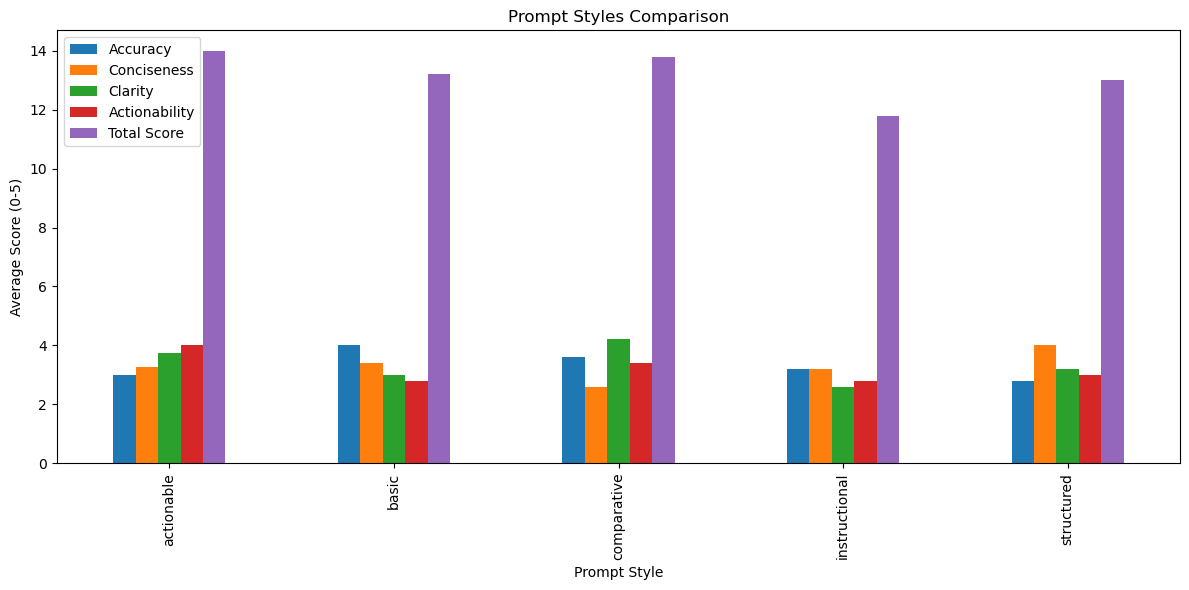

In [4]:
if __name__ == "__main__":
    main()